In [18]:
import Pkg
Pkg.activate(".");

  Activating project at `~/Documents/MPSTime.jl`


In [154]:
using MPSTime
using Distributions
using Plots
using StatsPlots
using Random
using ProgressMeter
using Plots.PlotMeasures
default(;fontfamily = "Computer Modern", xtickfont=12, ytickfont=12, guidefont=12, 
    bottom_margin=8mm, left_margin=8mm, right_margin=8mm, titlefont=12, c=palette(:tab10))

# MAE for two noise processes

Two noises processes, same mean, same variance. If we subtract one from the other, at each time point, then on average the errors should cancel out.
If we take the mean of the residuals, it should be close to zero.
However, if we take the mean absolute error (MAE), then residuals

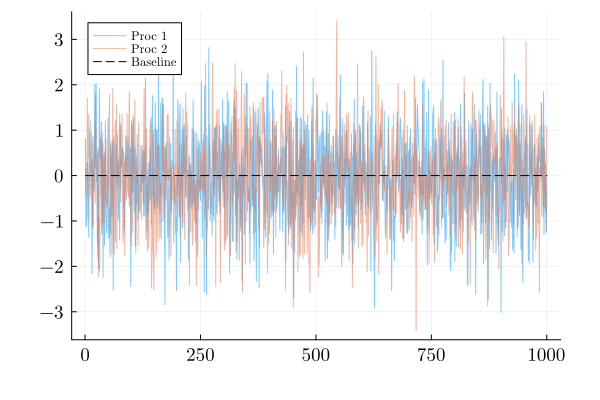

In [284]:
proc1 = rand(Xoshiro(123), Normal(0, 1), 1000);
proc2 = rand(Xoshiro(14), Normal(0, 1), 1000);
baseline = zeros(1000);
plot(proc1, label="Proc 1", c=1, alpha=0.5)
plot!(proc2, label="Proc 2", c=2, alpha=0.5)
plot!(baseline, label="Baseline", c=:black, ls=:dash)

In [287]:
mean(abs.(proc1 - proc2))

1.0920440814876948

In [39]:
out = MPSTime.residual_error(baseline, proc1)

1000-element Vector{Float64}:
  0.8082879284649668
 -1.1220725081141734
 -1.1046361023292959
 -0.4169926351649334
  0.28758798062385577
  0.2298186980518676
 -0.4217686643996927
 -1.355590621101197
  0.0694591410918936
 -0.11732280453081337
  ⋮
 -0.9054384415976374
  1.8480179360554947
 -1.298457080571386
  0.5967225756464682
  0.43195593259853066
 -0.7970966385937522
 -0.06253190718252355
 -1.2505328746000024
 -0.3463702447057351

Plot the distribution of residuals, should be zero-centred

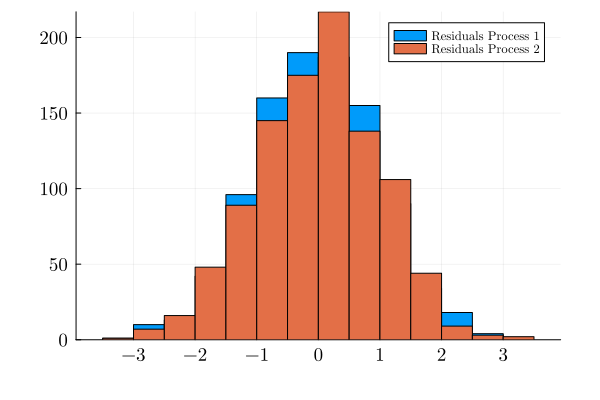

In [288]:
residuals_proc1 = proc1 - baseline
residuals_proc2 = proc2 - baseline
histogram(residuals_proc1, label="Residuals Process 1", c=1)
histogram!(residuals_proc2, label="Residuals Process 2", c=2)

# Plotting Resdiuals

Take the 64 interval experiment for example. 

In [ ]:
nintervals = 64
sample_pts = [2pi * k/nintervals for k in 0:nintervals-1]
intervals = [sample_pts[6], sample_pts[7]]
intervals[2] - intervals[1]

0.09817477042468103

In [316]:
T = 100
period = 30.0 # fix period
slope = 1.0 # fix slope 
phase_train = intervals
n_test = 250
n_train = 500
sigma = 0.1
train, train_info = trendy_sine(T, n_train; period=period, slope=slope, phase=phase_train, sigma=sigma, rng=Xoshiro(12345));
phase_test = collect(LinRange(intervals[1], intervals[2], n_test))
test = Matrix{Float64}(undef, n_test, T)
gt = Matrix{Float64}(undef, n_test, T)
test_phases = Vector{Float64}(undef, n_test)
for i in 1:n_test
    inst, inf = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=sigma, rng=Xoshiro(3456));
    gt_inst, _ = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=sigma) # noisey gt with noise drawn from the same distribution
    test_phases[i] = inf[:phase][1]
    test[i, :] = inst
    gt[i, :] = gt_inst
end
opts = MPSOptions(d=8, chi_max=60, nsweeps=20, eta=0.1, sigmoid_transform=false);
mps, _, _ = fitMPS(train, opts);

Generating initial weight MPS with bond dimension χ_init = 4
        using random state 1234.
Initialising train states.


┌ Warning: Not using MKL BLAS, which may lead to worse performance.
│ To fix this, Import MPSTime into Julia first or use the MKL package
└ @ MPSTime /Users/jmoo2880/Documents/MPSTime.jl/src/Training/RealRealHighDimension.jl:715


blas_name = "LBTConfig([ILP64] libopenblas64_.dylib)"
Using 1 iterations per update.
Training KL Div. 125.71110664117214 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [1/20]
Backward sweep finished.
Starting forward sweep: [1/20]
Finished sweep 1. Time for sweep: 12.59s
Training KL Div. -96.91955570093448 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [2/20]
Backward sweep finished.
Starting forward sweep: [2/20]
Finished sweep 2. Time for sweep: 69.84s
Training KL Div. -97.3207891994291 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [3/20]
Backward sweep finished.
Starting forward sweep: [3/20]
Finished sweep 3. Time for sweep: 76.19s
Training KL Div. -97.47452451895931 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [4/20]
Backward sweep finished.
Starting forward sweep: [4/20]
Finis

In [328]:
imp = init_imputation_problem(mps, test)

Initialising train states.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                         Summary:

 - Dataset has 500 training samples and 250 testing samples.
Slicing MPS into individual states...
 - 1 class(es) were detected.
 - Time independent encoding - Legendre - detected.
 - d = 8, chi_max = 60
Re-encoding the training data to get the encoding arguments...

 Created 1 ImputationProblem struct(s) containing class-wise mps and test samples.


ImputationProblem(ITensors.ITensorMPS.MPS[ITensors.ITensorMPS.MPS
[1] ((dim=8|id=205|"Site,n=1"), (dim=5|id=7|"Link,l=1"))
[2] ((dim=8|id=177|"Site,n=2"), (dim=5|id=7|"Link,l=1"), (dim=18|id=285|"Link,l=2"))
[3] ((dim=8|id=536|"Site,n=3"), (dim=18|id=285|"Link,l=2"), (dim=45|id=564|"Link,l=3"))
[4] ((dim=8|id=983|"Site,n=4"), (dim=45|id=564|"Link,l=3"), (dim=60|id=857|"Link,l=4"))
[5] ((dim=8|id=808|"Site,n=5"), (dim=60|id=857|"Link,l=4"), (dim=60|id=646|"Link,l=5"))
[6] ((dim=8|id=305|"Site,n=6"), (dim=60|id=646|"Link,l=5"), (dim=60|id=895|"Link,l=6"))
[7] ((dim=8|id=951|"Site,n=7"), (dim=60|id=895|"Link,l=6"), (dim=60|id=993|"Link,l=7"))
[8] ((dim=8|id=459|"Site,n=8"), (dim=60|id=993|"Link,l=7"), (dim=60|id=580|"Link,l=8"))
[9] ((dim=8|id=300|"Site,n=9"), (dim=60|id=580|"Link,l=8"), (dim=60|id=906|"Link,l=9"))
[10] ((dim=8|id=804|"Site,n=10"), (dim=60|id=906|"Link,l=9"), (dim=60|id=246|"Link,l=10"))
[11] ((dim=8|id=970|"Site,n=11"), (dim=60|id=246|"Link,l=10"), (dim=60|id=889|"Link,l

In [435]:
class = 0
method = :median
pm = 0.5 # 50% data missing
instance = 125
_, impute_sites = mar(test[instance, :], pm; rng=Xoshiro(355)) 
imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=true);

In [438]:
@show mps_me = mean(stats[1][:MPS_residuals]);
@show nn_me = mean(stats[2][:NN_residuals]);
@show gt_me = mean(gt[instance, impute_sites] - test[instance, impute_sites])
@show gt_mae = MPSTime.mae(gt[4, impute_sites], test[4, impute_sites])
@show mps_mae = stats[1][:MPS_MAE];
@show nn_mae = stats[2][:NN_MAE];
residuals_gt = gt[instance, impute_sites] - test[instance, impute_sites];

mps_me = mean((stats[1])[:MPS_residuals]) = -0.010068917948998416
nn_me = mean((stats[2])[:NN_residuals]) = 0.015363280299147882
gt_me = mean(gt[instance, impute_sites] - test[instance, impute_sites]) = 0.00332185518000174
gt_mae = MPSTime.mae(gt[4, impute_sites], test[4, impute_sites]) = 0.10672903622198113
mps_mae = (stats[1])[:MPS_MAE] = 0.08256002332574564
nn_mae = (stats[2])[:NN_MAE] = 0.1062059443722745


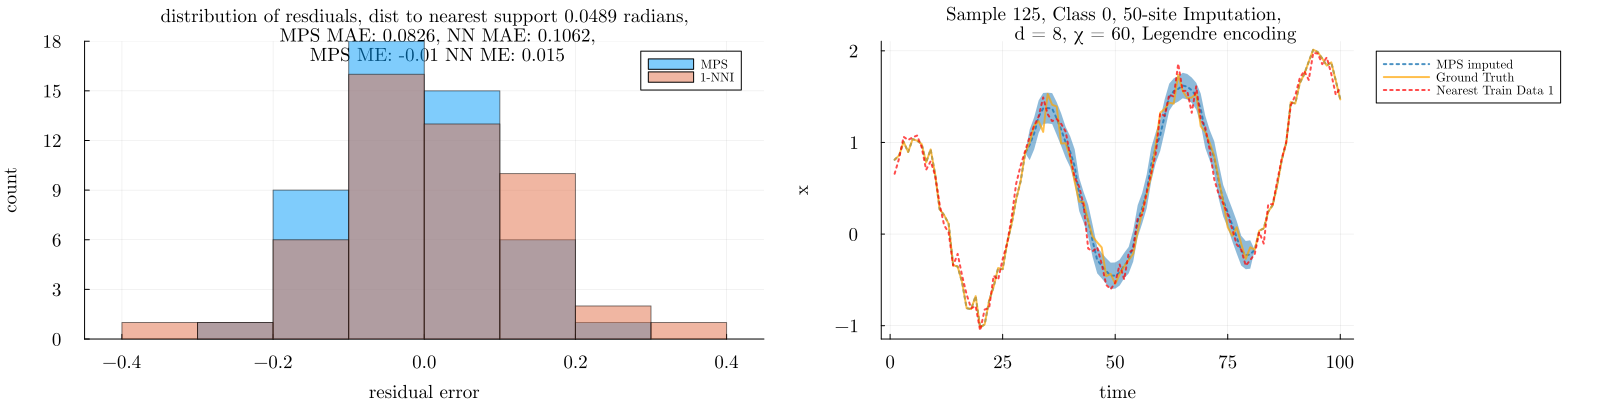

In [439]:
gt_phase = phase_test[instance, :]
dist_to_support = round(minimum(abs.(phase_train .- gt_phase)); digits=4)
p1 = histogram(stats[1][:MPS_residuals], label="MPS", bins=7, c=1, xlabel="residual error", ylabel="count", 
    title="distribution of resdiuals, dist to nearest support $dist_to_support radians,
    MPS MAE: $(round(mps_mae; digits=4)), NN MAE: $(round(nn_mae; digits=4)),
    MPS ME: $(round(mps_me; digits=3)) NN ME: $(round(nn_me; digits=3))", alpha=0.5)
p1 = histogram!(stats[2][:NN_residuals], label="1-NNI", c=2, alpha=0.5, bins=7)
#p1 = histogram!(residuals_gt, label="Correct Phase, Noisy", c=3, alpha=0.5, bins=7)
p2 = plot(plots...)
plot(p1, p2, size=(1600, 400))

Interpolating between gaps again...

In [224]:
function run_focused_interval_experiment(intervals::Vector, training_budget::Int, n_test::Int; sigma=0.1, d::Int=8)

    sample_pts = intervals
    println("Sampling phases: $sample_pts")
    # setup training parameters
    T = 100
    period = 30.0 # fix period
    slope = 1.0 # fix slope 
    phase_train = sample_pts
    train, train_info = trendy_sine(T, training_budget; period=period, slope=slope, phase=phase_train, sigma=sigma, rng=Xoshiro(12345));
    phase_test = collect(LinRange(intervals[1], intervals[2], n_test))
    test = Matrix{Float64}(undef, n_test, T)
    gt = Matrix{Float64}(undef, n_test, T)
    test_phases = Vector{Float64}(undef, n_test)
    for i in 1:n_test
        inst, inf = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=sigma, rng=Xoshiro(3456));
        gt_inst, _ = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=0.0) # noise-free gt
        test_phases[i] = inf[:phase][1]
        test[i, :] = inst
        gt[i, :] = gt_inst
    end
    opts = MPSOptions(d=d, chi_max=60, nsweeps=20, eta=0.1, sigmoid_transform=false);
    mps, _, _ = fitMPS(train, opts);
    imp = init_imputation_problem(mps, test)
    class = 0
    method = :median
    pm = 0.5 # 50% data missing
    score_mps = Vector{Dict}(undef, size(test, 1))
    score_nn = Vector{Dict}(undef, size(test, 1))
    score_gt = Vector{Dict}(undef, size(test, 1))
    for instance in 1:size(test, 1)
        println("Evaluating instance $instance")
        window_loc_score_mps = []
        window_loc_score_nn = []
        window_loc_score_nf_gt = []
        for i in 1:5
            _, impute_sites = mar(test[instance, :], pm) # randomly generate missing data locations each time
            imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=false);
            # extract relevant stuff
            nfgt_mae = MPSTime.mae(gt[instance, impute_sites], test[instance, impute_sites])
            nfgt_me = MPSTime.me(gt[instance, impute_sites], test[instance, impute_sites])
            #nfgt_residuals = MPSTime.residual_error(gt[instance, impute_sites], test[instance, impute_sites]) # vector
            # noise free ground-truth MAE and ME + residuals
            mps_errors = Dict(:MAE => stats[1][:MPS_MAE], :ME => stats[1][:MPS_ME])
            nn_errors = Dict(:MAE => stats[2][:NN_MAE], :ME => stats[2][:NN_ME])
            gt_errors = Dict(:MAE => nfgt_mae, :ME => nfgt_me)
            push!(window_loc_score_mps, mps_errors)
            push!(window_loc_score_nn, nn_errors)
            push!(window_loc_score_nf_gt, gt_errors)
        end
        # take averages across window locations
        score_mps[instance] = Dict(:mean_mae => mean([window_loc_score_mps[i][:MAE] for i in 1:5]), :mean_me => mean([window_loc_score_mps[i][:ME] for i in 1:5]))
        score_nn[instance] = Dict(:mean_mae => mean([window_loc_score_nn[i][:MAE] for i in 1:5]), :mean_me => mean([window_loc_score_nn[i][:ME] for i in 1:5]))
        score_gt[instance] = Dict(:mean_mae => mean([window_loc_score_nf_gt[i][:MAE] for i in 1:5]), :mean_me => mean([window_loc_score_nf_gt[i][:ME] for i in 1:5]))
    end
    
    return score_mps, score_nn, score_gt, train_info, phase_test
    
end

run_focused_interval_experiment (generic function with 1 method)

In [413]:
nintervals = 16
sample_pts = [2pi * k/nintervals for k in 0:nintervals-1]
intervals = [sample_pts[6], sample_pts[7]]
intervals[2] - intervals[1]

0.39269908169872414

In [226]:
score_mps8, score_nn8, score_gt8, train_info8, phase_test8 = run_focused_interval_experiment(intervals, 50, 20; sigma=0.0, d=8)

Sampling phases: [1.9634954084936207, 2.356194490192345]
Generating initial weight MPS with bond dimension χ_init = 4
        using random state 1234.
Initialising train states.
blas_name = "LBTConfig([ILP64] libopenblas64_.dylib)"
Using 1 iterations per update.
Training KL Div. 105.05858645023989 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [1/20]
Backward sweep finished.

┌ Warning: Not using MKL BLAS, which may lead to worse performance.
│ To fix this, Import MPSTime into Julia first or use the MKL package
└ @ MPSTime /Users/jmoo2880/Documents/MPSTime.jl/src/Training/RealRealHighDimension.jl:715



Starting forward sweep: [1/20]
Finished sweep 1. Time for sweep: 0.2s
Training KL Div. -123.82948147806023 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [2/20]
Backward sweep finished.
Starting forward sweep: [2/20]
Finished sweep 2. Time for sweep: 0.2s
Training KL Div. -124.01214030043755 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [3/20]
Backward sweep finished.
Starting forward sweep: [3/20]
Finished sweep 3. Time for sweep: 0.19s
Training KL Div. -124.03864998881946 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [4/20]
Backward sweep finished.
Starting forward sweep: [4/20]
Finished sweep 4. Time for sweep: 0.19s
Training KL Div. -124.04367396327163 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [5/20]
Backward sweep finished.
Starting forward sweep: [5/20]
Finished sweep 5. 

(Dict[Dict(:mean_me => -0.000810444142493156, :mean_mae => 0.024859249498165016), Dict(:mean_me => -0.0010978985901429564, :mean_mae => 0.0266736516562218), Dict(:mean_me => -0.002213220848101453, :mean_mae => 0.03190830559405949), Dict(:mean_me => -0.0024143256215760902, :mean_mae => 0.043399182216392454), Dict(:mean_me => -0.004621407824047229, :mean_mae => 0.05510530774741684), Dict(:mean_me => -3.239705348132144e-5, :mean_mae => 0.06903752129000032), Dict(:mean_me => 0.006841647963779477, :mean_mae => 0.07999444312348368), Dict(:mean_me => -0.002587990809608546, :mean_mae => 0.09387343191279444), Dict(:mean_me => -0.0014616084493187765, :mean_mae => 0.10670499249536906), Dict(:mean_me => -0.01714461867673418, :mean_mae => 0.12099877090346686), Dict(:mean_me => 0.005639387414188473, :mean_mae => 0.120707182914545), Dict(:mean_me => 0.01864405877537589, :mean_mae => 0.10720542936309214), Dict(:mean_me => 0.0006626239598779167, :mean_mae => 0.09775982404038783), Dict(:mean_me => 0.008

In [227]:
score_mps12, score_nn12, score_gt12, train_info12, phase_test12 = run_focused_interval_experiment(intervals, 50, 20; sigma=0.0, d=12)

Sampling phases: [1.9634954084936207, 2.356194490192345]
Generating initial weight MPS with bond dimension χ_init = 4
        using random state 1234.
Initialising train states.
blas_name = "LBTConfig([ILP64] libopenblas64_.dylib)"
Using 1 iterations per update.
Training KL Div. 108.65112819968583 | Training acc. 1.0.

┌ Warning: Not using MKL BLAS, which may lead to worse performance.
│ To fix this, Import MPSTime into Julia first or use the MKL package
└ @ MPSTime /Users/jmoo2880/Documents/MPSTime.jl/src/Training/RealRealHighDimension.jl:715



Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [1/20]
Backward sweep finished.
Starting forward sweep: [1/20]
Finished sweep 1. Time for sweep: 0.35s
Training KL Div. -163.8779422124044 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [2/20]
Backward sweep finished.
Starting forward sweep: [2/20]
Finished sweep 2. Time for sweep: 0.32s
Training KL Div. -164.08730616845986 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [3/20]
Backward sweep finished.
Starting forward sweep: [3/20]
Finished sweep 3. Time for sweep: 0.21s
Training KL Div. -164.12866748753953 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [4/20]
Backward sweep finished.
Starting forward sweep: [4/20]
Finished sweep 4. Time for sweep: 0.21s
Training KL Div. -164.14140242309338 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorit

(Dict[Dict(:mean_me => -0.00020048493572307583, :mean_mae => 0.01211219583584783), Dict(:mean_me => -0.001408461428967722, :mean_mae => 0.016350775320009385), Dict(:mean_me => 5.985591297312312e-5, :mean_mae => 0.02822054112406555), Dict(:mean_me => 0.004884821445219995, :mean_mae => 0.041462702327430746), Dict(:mean_me => -0.0010534187464208283, :mean_mae => 0.05473266555652734), Dict(:mean_me => -0.0034819906902944587, :mean_mae => 0.06642973465176676), Dict(:mean_me => 0.0006722306413582083, :mean_mae => 0.07955562211250458), Dict(:mean_me => 0.0036718955494747588, :mean_mae => 0.09267804197554241), Dict(:mean_me => -0.015368540197859288, :mean_mae => 0.10603567019365559), Dict(:mean_me => -0.02040372105823952, :mean_mae => 0.11848770640055939), Dict(:mean_me => 0.009996826414606391, :mean_mae => 0.11591739741791454), Dict(:mean_me => 0.0060286813567865544, :mean_mae => 0.10273335035029871), Dict(:mean_me => -0.0005375316060813502, :mean_mae => 0.09434644841438937), Dict(:mean_me =>

In [228]:
score_mps16, score_nn16, score_gt16, train_info16, phase_test16 = run_focused_interval_experiment(intervals, 50, 20; sigma=0.0, d=16)

Sampling phases: [1.9634954084936207, 2.356194490192345]
Generating initial weight MPS with bond dimension χ_init = 4
        using random state 1234.
Initialising train states.
blas_name = "LBTConfig([ILP64] libopenblas64_.dylib)"
Using 1 iterations per update.
Training KL Div. 104.41922085931864 | Training acc. 1.0.

┌ Warning: Not using MKL BLAS, which may lead to worse performance.
│ To fix this, Import MPSTime into Julia first or use the MKL package
└ @ MPSTime /Users/jmoo2880/Documents/MPSTime.jl/src/Training/RealRealHighDimension.jl:715



Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [1/20]
Backward sweep finished.
Starting forward sweep: [1/20]
Finished sweep 1. Time for sweep: 0.48s
Training KL Div. -192.6658014243394 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [2/20]
Backward sweep finished.
Starting forward sweep: [2/20]
Finished sweep 2. Time for sweep: 0.46s
Training KL Div. -192.8603829329272 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [3/20]
Backward sweep finished.
Starting forward sweep: [3/20]
Finished sweep 3. Time for sweep: 0.31s
Training KL Div. -192.89781481932891 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [4/20]
Backward sweep finished.
Starting forward sweep: [4/20]
Finished sweep 4. Time for sweep: 0.39s
Training KL Div. -192.9081262175337 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm

(Dict[Dict(:mean_me => -0.00016425224417549502, :mean_mae => 0.007552261496939783), Dict(:mean_me => -0.0001894396536645426, :mean_mae => 0.01364316579307758), Dict(:mean_me => 0.0015126313639521325, :mean_mae => 0.02602921902010316), Dict(:mean_me => -0.001661796536206198, :mean_mae => 0.039891448750806205), Dict(:mean_me => -0.006831487403312492, :mean_mae => 0.05202394678382538), Dict(:mean_me => -0.00024598178891318406, :mean_mae => 0.06492096010499776), Dict(:mean_me => -0.004923776601800507, :mean_mae => 0.0812138410480804), Dict(:mean_me => 0.0002663992024639145, :mean_mae => 0.09408060173215992), Dict(:mean_me => 0.0021404525406018443, :mean_mae => 0.10415068685652815), Dict(:mean_me => -0.007397531799791931, :mean_mae => 0.12085428052001874), Dict(:mean_me => 0.0054370972554925855, :mean_mae => 0.12021363054895307), Dict(:mean_me => 0.0021748970820429574, :mean_mae => 0.10598337030603396), Dict(:mean_me => 0.007354363469062278, :mean_mae => 0.09216029757513003), Dict(:mean_me 

In [239]:
mps_maes8 = [score_mps8[i][:mean_mae] for i in 1:length(score_mps8)];
mps_mes8 = [score_mps8[i][:mean_me] for i in 1:length(score_mps8)];
mps_maes12 = [score_mps12[i][:mean_mae] for i in 1:length(score_mps12)];
mps_mes12 = [score_mps12[i][:mean_me] for i in 1:length(score_mps12)];
mps_maes16 = [score_mps16[i][:mean_mae] for i in 1:length(score_mps16)];
mps_mes16 = [score_mps16[i][:mean_me] for i in 1:length(score_mps16)];

nn_maes = [score_nn[i][:mean_mae] for i in 1:length(score_nn8)];
nn_mes = [score_nn[i][:mean_me] for i in 1:length(score_nn8)];

gt_maes = [score_gt[i][:mean_mae] for i in 1:length(score_gt8)];
gt_mes = [score_gt[i][:mean_me] for i in 1:length(score_gt8)];

In [235]:
round(diff(intervals)[1]; digits=3)

0.393

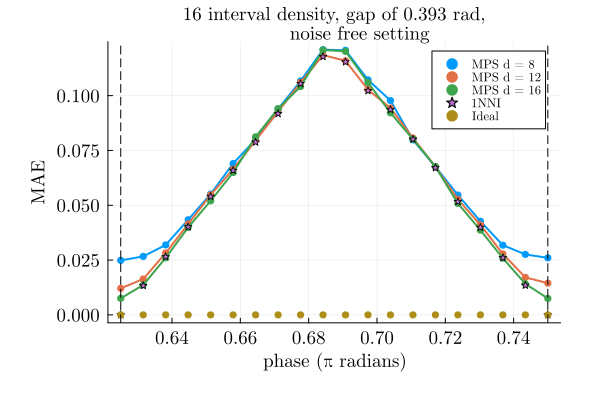

In [278]:
scatter(phase_test/pi, mps_maes8, c=1, label="MPS d = 8", xlabel="phase (π radians)", 
    ylabel="MAE", msw=0, title="16 interval density, gap of $(round(diff(intervals)[1]; digits=3)) rad,
        noise free setting")
plot!(phase_test/pi, mps_maes8, c=1, label="", lw=2)
scatter!(phase_test/pi, mps_maes12, c=2, label="MPS d = 12", msw=0)
plot!(phase_test/pi, mps_maes12, c=2, label="", lw=2)
scatter!(phase_test/pi, mps_maes16, c=3, label="MPS d = 16", msw=0)
plot!(phase_test/pi, mps_maes16, c=3, label="", lw=2)
scatter!(phase_test/pi, nn_maes, c=4, label="1NNI", msw=1, markershape=:star)
scatter!(phase_test/pi, gt_maes, c=5, label="Ideal", msw=0)
vline!([intervals/pi], ls=:dash, c=:black, label="")
#savefig("16interval_density_equivalent_mae_multiple_d.svg")

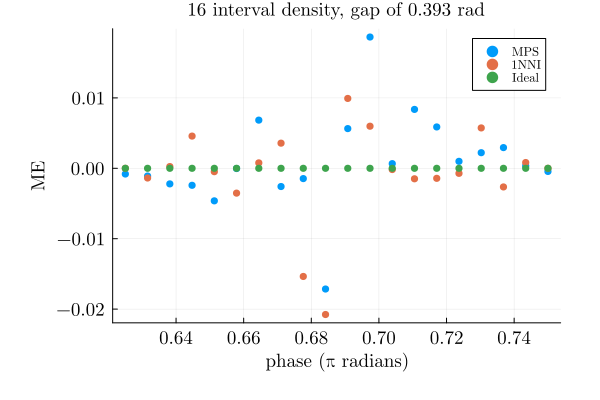

In [280]:
scatter(phase_test/pi, mps_mes8, c=1, label="MPS", xlabel="phase (π radians)", 
    ylabel="ME", msw=0, title="16 interval density, gap of $(round(diff(intervals)[1]; digits=3)) rad")
scatter!(phase_test/pi, nn_mes, c=2, label="1NNI", msw=0)
scatter!(phase_test/pi, gt_mes, c=3, label="Ideal", msw=0)
#savefig("16interval_density_equivalent_me_new.svg")